# A3 — Classificador com CNN pré-treinada (transfer learning por feature extraction)

**Disciplina:** Visão Computacional com CNNs e Transformers [26E3_3] — INFNET · **Aluno:** Lucas de Oliveira Ferreira

**Dataset:** [Images Dataset](https://www.kaggle.com/datasets/pavansanagapati/images-dataset) (Pavan Sanagapati, CC0) — 7 categorias de objetos, ~1.800 imagens.

| Requisito | Valor estimado (Colab T4) |
|---|---|
| GPU | T4 (16 GB) — usa < 3 GB de VRAM |
| RAM | ~3 GB |
| Disco | ~1,6 GB temporário (zip de 754 MB + extração; o zip pode ser apagado) |
| Tempo total | ~4–6 min no T4 (download ~2 min, extração de features < 1 min, treino da head < 1 min, testes de estresse ~1 min) — **medido: 1,5 min** numa RTX 3050 6 GB, sem contar o download |

**Como rodar:** `Ambiente de execução → Alterar tipo → T4 GPU` e depois `Executar tudo`. Não é preciso montar o Drive nem ter `kaggle.json`: o download usa o endpoint público do Kaggle.

**Uso de IA:** código e texto elaborados com apoio do Claude (Anthropic), revisados e executados pelo aluno; os números e gráficos são os outputs reais deste notebook.

**Base nas aulas:** Aula 01 (TorchVision Weights API, congelamento do backbone, troca da `fc`, Adam lr=1e-3, `weights.transforms()`), Aula 03 (feature extraction com embeddings em cache), Aula 08 (acurácia por classe, balanced accuracy, riscos de augmentation e normalização).

## 0. Setup

In [1]:
import os, sys, time, json, random, hashlib, zipfile, shutil, urllib.request
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torchvision
from torchvision.models import resnet50, ResNet50_Weights
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

IN_COLAB = "google.colab" in sys.modules
DATA_ROOT = Path(os.environ.get("DATA_ROOT", "/content/data" if IN_COLAB else "data")).resolve()
FIG_DIR = Path(os.environ.get("FIG_DIR", "figs/A3")).resolve()
FIG_DIR.mkdir(parents=True, exist_ok=True)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

def seed_everything(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True; torch.backends.cudnn.benchmark = False

CONFIG = dict(seed=42, val_size=0.15, test_size=0.15, batch_size=32, epochs=15, lr=1e-3, num_workers=2 if os.name != "nt" else 0)
seed_everything(CONFIG["seed"])

def savefig(name):
    plt.savefig(FIG_DIR / f"{name}.png", dpi=150, bbox_inches="tight")

print("torch", torch.__version__, "| torchvision", torchvision.__version__, "| device", DEVICE,
      "|", torch.cuda.get_device_name(0) if DEVICE == "cuda" else "")
print("DATA_ROOT =", DATA_ROOT)

torch 2.14.1+cu126 | torchvision 0.29.1+cu126 | device cuda | NVIDIA GeForce RTX 3050 6GB Laptop GPU
DATA_ROOT = .\data


## 1. Download e extração

O endpoint `https://www.kaggle.com/api/v1/datasets/download/<owner>/<dataset>` serve datasets públicos sem autenticação (redireciona para uma URL assinada do Google Cloud Storage). Se falhar, o fallback é `kagglehub` (que pode pedir credencial).

O zip traz uma **cópia duplicada de todo o dataset em `data/data/`** — ela é ignorada; usar as duas cópias duplicaria imagens e vazaria exemplos entre treino e teste.

In [2]:
class Archive:
    """Lê membros de um .zip (download anônimo) ou de uma pasta (fallback kagglehub)."""
    def __init__(self, path):
        self.path = Path(path)
        self.zf = zipfile.ZipFile(self.path) if self.path.is_file() else None
    def names(self):
        if self.zf:
            return [n for n in self.zf.namelist() if not n.endswith("/")]
        return [p.relative_to(self.path).as_posix() for p in self.path.rglob("*") if p.is_file()]
    def extract(self, name, dest_root):
        out = Path(dest_root) / name
        out.parent.mkdir(parents=True, exist_ok=True)
        if self.zf:
            with self.zf.open(name) as src, open(out, "wb") as dst:
                shutil.copyfileobj(src, dst)
        else:
            shutil.copy(self.path / name, out)
        return out

def kaggle_archive(ref, name):
    zpath = DATA_ROOT / "_zips" / f"{name}.zip"
    if zpath.exists():
        return Archive(zpath)
    zpath.parent.mkdir(parents=True, exist_ok=True)
    url = f"https://www.kaggle.com/api/v1/datasets/download/{ref}"
    try:
        t0 = time.time()
        with urllib.request.urlopen(url, timeout=600) as r, open(f"{zpath}.part", "wb") as f:
            shutil.copyfileobj(r, f, 1 << 20)
        os.replace(f"{zpath}.part", zpath)
        print(f"{ref}: {zpath.stat().st_size/1e6:.0f} MB em {time.time()-t0:.0f}s")
        return Archive(zpath)
    except Exception as e:
        print("Download anônimo falhou:", e, "→ tentando kagglehub")
        import kagglehub
        return Archive(kagglehub.dataset_download(ref))

IMG_DIR = DATA_ROOT / "images"
if not (IMG_DIR / "data").exists():
    arc = kaggle_archive("pavansanagapati/images-dataset", "images")
    members = [n for n in arc.names() if n.startswith("data/") and not n.startswith("data/data/")]
    for n in members:
        arc.extract(n, IMG_DIR)
    print("extraídos:", len(members))
SRC = IMG_DIR / "data"
CLASSES = sorted(p.name for p in SRC.iterdir() if p.is_dir() and p.name != "data")
print("classes:", CLASSES)

classes: ['bike', 'cars', 'cats', 'dogs', 'flowers', 'horses', 'human']


## 2. Inventário e qualidade dos dados

Antes de treinar: contagem por classe, formatos, imagens corrompidas, duplicatas exatas (MD5), resolução e estatísticas de cor. Essas estatísticas também embasam a discussão do item 3.2 (quais augmentations fazem sentido para cada classe).

In [3]:
rows = []
for c in CLASSES:
    for p in sorted((SRC / c).iterdir()):
        if not p.is_file():
            continue
        rec = dict(path=str(p), label=c, ext=p.suffix.lower())
        try:
            with Image.open(p) as im:
                rec.update(mode=im.mode, w=im.width, h=im.height)
                rgb = im.convert("RGB").resize((64, 64))
            a = np.asarray(rgb, dtype=np.float32) / 255.0
            hsv = np.asarray(rgb.convert("HSV"), dtype=np.float32) / 255.0
            rec.update(mean_r=a[..., 0].mean(), mean_g=a[..., 1].mean(), mean_b=a[..., 2].mean(),
                       saturation=hsv[..., 1].mean(), brightness=hsv[..., 2].mean(),
                       is_gray=float(np.abs(a[..., 0] - a[..., 1]).mean() + np.abs(a[..., 1] - a[..., 2]).mean() < 0.01),
                       md5=hashlib.md5(p.read_bytes()).hexdigest(), ok=True)
        except Exception as e:
            rec.update(ok=False, error=str(e))
        rows.append(rec)
df = pd.DataFrame(rows)
print("arquivos:", len(df), "| corrompidos:", int((~df.ok).sum()))
dups = df[df.duplicated("md5", keep=False)].sort_values("md5")
print("duplicatas exatas (MD5):", len(dups), "arquivos em", dups.md5.nunique(), "grupos")
if len(dups):
    print("duplicatas entre classes diferentes:", int(dups.groupby("md5").label.nunique().gt(1).sum()), "grupos")

arquivos: 1803 | corrompidos: 0
duplicatas exatas (MD5): 78 arquivos em 39 grupos
duplicatas entre classes diferentes: 0 grupos


In [4]:
summary = df[df.ok].groupby("label").agg(n=("path", "size"), largura_mediana=("w", "median"), altura_mediana=("h", "median"),
                                         aspect_ratio=("w", lambda s: float(np.median(s / df.loc[s.index, "h"]))),
                                         saturacao=("saturation", "mean"), brilho=("brightness", "mean"),
                                         frac_cinza=("is_gray", "mean"))
summary["formatos"] = df[df.ok].groupby("label").ext.agg(lambda s: dict(Counter(s)))
summary.round(3)

,n,largura_mediana,altura_mediana,aspect_ratio,saturacao,brilho,frac_cinza,formatos
label,,,,,,,,
bike,365,640.0,480.0,1.333,0.202,0.438,0.000,{'.bmp': 365}
cars,420,640.0,480.0,1.333,0.150,0.528,0.000,{'.bmp': 420}
cats,202,460.0,374.0,1.327,0.241,0.502,0.000,{'.jpg': 202}
dogs,202,439.5,374.0,1.253,0.276,0.513,0.000,{'.jpg': 202}
flowers,210,128.0,128.0,1.000,0.424,0.498,0.000,{'.png': 210}
horses,202,259.0,194.0,1.335,0.362,0.614,0.015,{'.jpg': 202}
human,202,188.0,257.5,0.731,0.251,0.554,0.020,{'.jpg': 202}


Remoção de corrompidas e duplicatas exatas (mantém a primeira ocorrência; se uma imagem idêntica aparecer em duas classes, ambas são descartadas por terem rótulo ambíguo).

imagens após limpeza: 1764 (removidas: 39 )


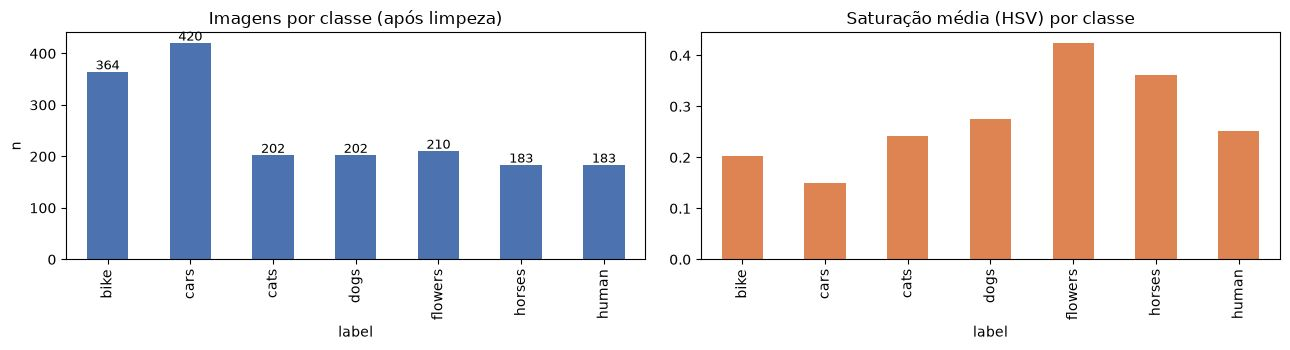

In [5]:
clean = df[df.ok].copy()
conflict = clean.groupby("md5").label.nunique()
clean = clean[~clean.md5.isin(conflict[conflict > 1].index)].drop_duplicates("md5")
print("imagens após limpeza:", len(clean), "(removidas:", len(df) - len(clean), ")")
counts = clean.label.value_counts().reindex(CLASSES)

fig, ax = plt.subplots(1, 2, figsize=(13, 3.6))
counts.plot.bar(ax=ax[0], color="#4C72B0"); ax[0].set_title("Imagens por classe (após limpeza)"); ax[0].set_ylabel("n")
for i, v in enumerate(counts.values): ax[0].text(i, v + 5, str(v), ha="center", fontsize=9)
summary.loc[CLASSES, "saturacao"].plot.bar(ax=ax[1], color="#DD8452"); ax[1].set_title("Saturação média (HSV) por classe")
plt.tight_layout(); savefig("01_distribuicao_classes"); plt.show()

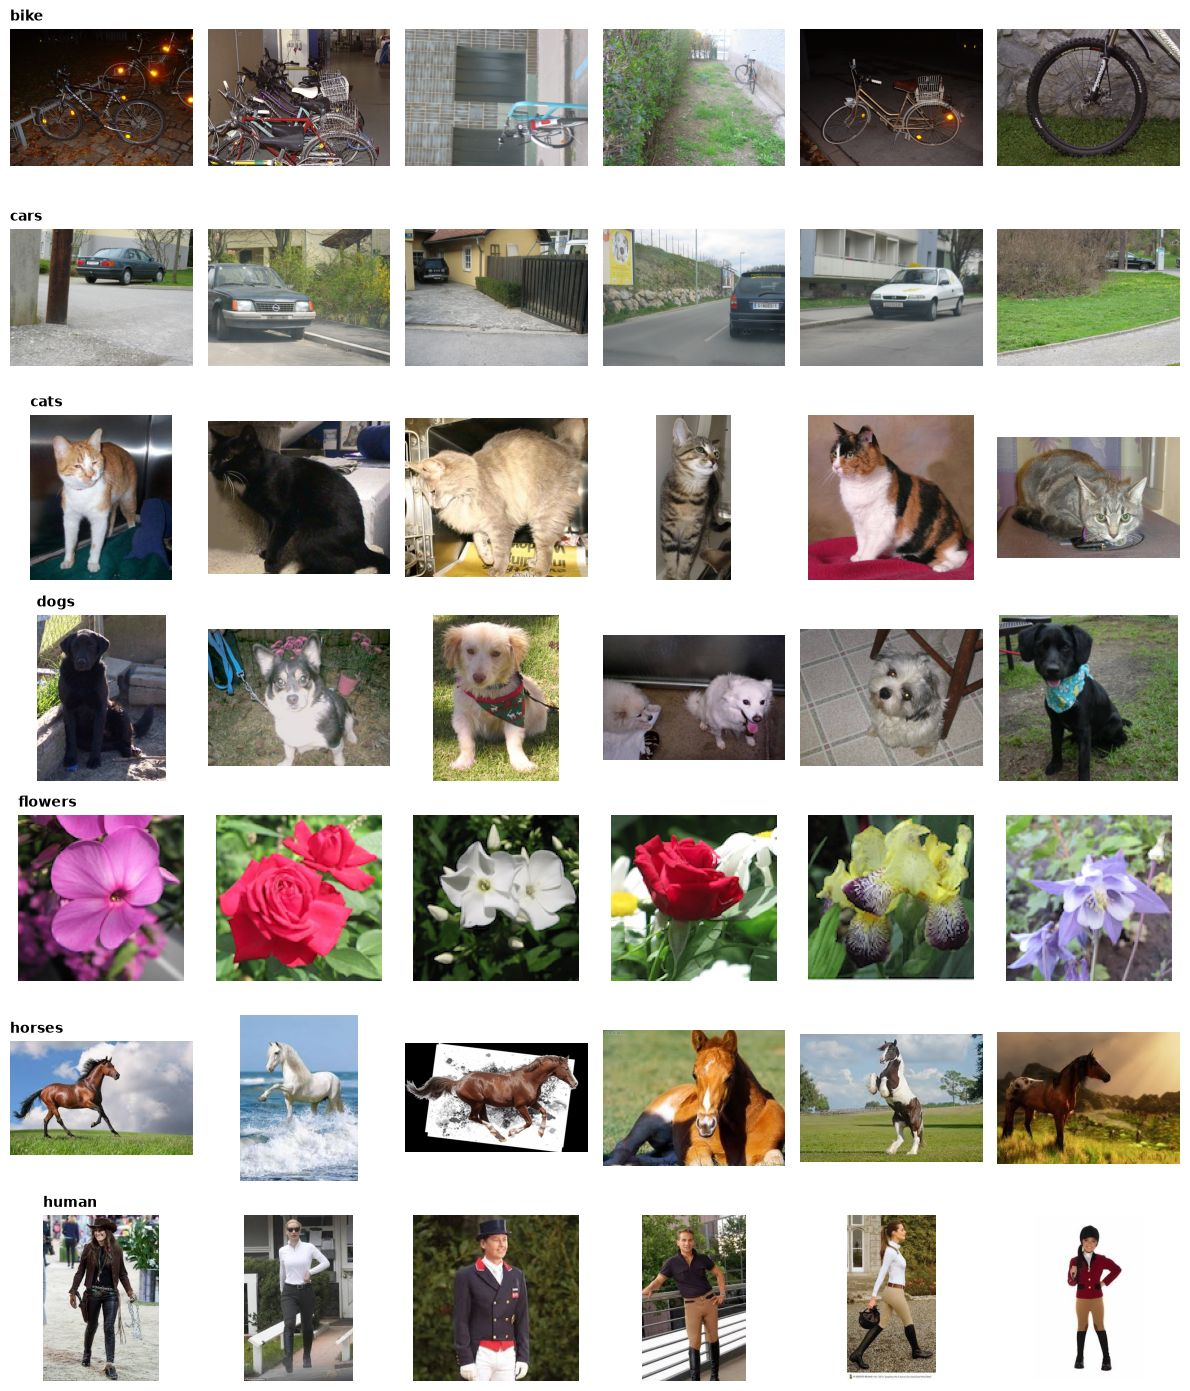

In [6]:
fig, axes = plt.subplots(len(CLASSES), 6, figsize=(12, 2.0 * len(CLASSES)))
for i, c in enumerate(CLASSES):
    sample = clean[clean.label == c].sample(6, random_state=0)
    for j, p in enumerate(sample.path):
        axes[i, j].imshow(Image.open(p).convert("RGB")); axes[i, j].axis("off")
    axes[i, 0].set_title(c, loc="left", fontsize=10, fontweight="bold")
plt.tight_layout(); savefig("02_exemplos_por_classe"); plt.show()

## 3. Split estratificado 70/15/15

Estratificar preserva a proporção de cada classe nos três conjuntos (com `cars` ≈ 2× `cats`, um split aleatório puro pode deixar classes sub-representadas na validação). O teste fica intocado até a avaliação final [Aula 08].

In [7]:
idx_train, idx_tmp = train_test_split(clean.index, test_size=CONFIG["val_size"] + CONFIG["test_size"],
                                      stratify=clean.label, random_state=CONFIG["seed"])
idx_val, idx_test = train_test_split(idx_tmp, test_size=CONFIG["test_size"] / (CONFIG["val_size"] + CONFIG["test_size"]),
                                     stratify=clean.loc[idx_tmp, "label"], random_state=CONFIG["seed"])
splits = {"train": clean.loc[idx_train], "val": clean.loc[idx_val], "test": clean.loc[idx_test]}
cls2idx = {c: i for i, c in enumerate(CLASSES)}
pd.DataFrame({k: v.label.value_counts().reindex(CLASSES) for k, v in splits.items()}).assign(
    total=lambda d: d.sum(axis=1))

,train,val,test,total
label,,,,
bike,255,55,54,364
cars,294,63,63,420
cats,141,31,30,202
dogs,141,30,31,202
flowers,147,31,32,210
horses,128,27,28,183
human,128,28,27,183


## 4. Modelo: ResNet-50 pré-treinada, backbone congelado

**Por que ResNet-50.** Comparamos as candidatas compatíveis com o Colab T4 (16 GB de VRAM, ~65 TFLOPS em FP16), com números das tabelas do TorchVision e da Aula 01:

| Modelo | Parâmetros | GFLOPs | Top-1 ImageNet | Vetor de features | Observação |
|---|---|---|---|---|---|
| ResNet-18 | 11,7 M | 1,8 | 69,8% | 512 | features mais fracas |
| EfficientNet-B0 | 5,3 M | 0,4 | 77,7% | 1280 | a mais leve; boa para *edge* |
| **ResNet-50 (V2)** | **25,6 M** | **4,1** | **80,9%** | **2048** | **escolhida** |
| ViT-B/16 | 86,6 M | 17,6 | 81,1% | 768 | 4× mais cara, sem ganho de top-1 |

- **Capacidade do T4:** em *feature extraction* não há gradiente no backbone, então o custo é só de inferência. A VRAM medida na extração é impressa abaixo, e fica muito abaixo dos 16 GB do T4. A Aula 01 estima ~120 MB de pesos para a ResNet-50 em inferência, contra ~8,5 GB para treiná-la inteira com batch 64. Mesmo um fine-tuning futuro da ResNet-50 cabe no T4. Não há motivo de memória para escolher um modelo menor.
- **Número de classes:** são só **7 classes**, e a nova cabeça `Linear(2048, 7)` tem 14.343 parâmetros. Com ~176 imagens de treino por classe, uma cabeça linear desse tamanho tem dados de sobra e baixo risco de *overfitting*. Um backbone maior não ajudaria: o gargalo de uma cabeça linear é a **separabilidade** das features, não a capacidade do classificador.
- **Proximidade de domínio:** as 7 classes são objetos naturais que o próprio ImageNet cobre (várias raças de cães e gatos, *mountain bike*, *sports car*, *daisy*, *sorrel* etc.). As features de 2048 dimensões da ResNet-50, a mais forte das CNNs da tabela com custo moderado, já separam esses conceitos linearmente, como o t-SNE confirma adiante.
- **Por que não ViT aqui:** com backbone congelado e um domínio próximo do ImageNet, a ResNet-50 entrega a mesma ordem de top-1 que o ViT-B/16, com ¼ do custo. O ViT faz mais sentido quando se vai ajustar o backbone com dados suficientes (A1). A EfficientNet-B0 seria a escolha se a restrição fosse latência ou memória (implantação embarcada).

**Pré-processamento:** `weights.transforms()` — resize para 232, *center crop* 224 e normalização com média/desvio do ImageNet. É exatamente a distribuição que o backbone viu no pré-treino (Aula 01: pré-processamento errado gera "bugs silenciosos").

**Por que extrair as features uma vez (cache):** com o backbone congelado e sem augmentation, a saída do backbone para cada imagem é determinística. Calcular uma vez e treinar a camada linear sobre os vetores é matematicamente idêntico a passar a imagem pela rede a cada época, e muito mais rápido (Aula 03). A consequência — discutida no item 3.2 — é que augmentation online exige recalcular as features a cada época.

In [8]:
weights = ResNet50_Weights.IMAGENET1K_V2
preprocess = weights.transforms()
print(preprocess)

backbone = resnet50(weights=weights, progress=False)
backbone.fc = nn.Identity()
for p in backbone.parameters():
    p.requires_grad = False
backbone = backbone.eval().to(DEVICE)   # eval(): BatchNorm usa as estatísticas do pré-treino e não é atualizado
print("parâmetros do backbone (congelados):", sum(p.numel() for p in backbone.parameters()) / 1e6, "M")

class ImgDS(torch.utils.data.Dataset):
    def __init__(self, frame, tf):
        self.paths, self.y, self.tf = frame.path.tolist(), frame.label.map(cls2idx).tolist(), tf
    def __len__(self): return len(self.paths)
    def __getitem__(self, i): return self.tf(Image.open(self.paths[i]).convert("RGB")), self.y[i]

@torch.no_grad()
def extract(frame):
    dl = torch.utils.data.DataLoader(ImgDS(frame, preprocess), batch_size=64, num_workers=CONFIG["num_workers"])
    feats, ys = [], []
    for x, y in dl:
        with torch.autocast(device_type="cuda", enabled=DEVICE == "cuda"):
            feats.append(backbone(x.to(DEVICE)).float().cpu())
        ys.append(y)
    return torch.cat(feats), torch.cat(ys)

t0 = time.time()
F = {k: extract(v) for k, v in splits.items()}
print({k: tuple(v[0].shape) for k, v in F.items()}, f"| extração: {time.time()-t0:.0f}s")
if DEVICE == "cuda":
    print(f"VRAM máxima alocada na extração: {torch.cuda.max_memory_allocated() / 1e9:.2f} GB (T4: 16 GB)")

ImageClassification(
    crop_size=[224]
    resize_size=[232]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


parâmetros do backbone (congelados): 23.508032 M


{'train': (1234, 2048), 'val': (265, 2048), 'test': (265, 2048)} | extração: 24s
VRAM máxima alocada na extração: 0.49 GB (T4: 16 GB)


## 5. Item 3.1 — treino da nova camada (um treino)

A `fc` original (2048 → 1000 classes do ImageNet) é substituída por `nn.Linear(2048, 7)`. Só esses 14.343 parâmetros são treinados.

**Hiperparâmetros** (receita da Aula 01): Adam com lr = 1e-3 (taxa padrão do Adam; adequada porque a camada parte de inicialização aleatória e o problema é convexo em relação a ela), batch 32, 15 épocas, cross-entropy. Guardamos o estado da época com menor loss de validação.

In [9]:
seed_everything(CONFIG["seed"])
head = nn.Linear(2048, len(CLASSES)).to(DEVICE)
opt = torch.optim.Adam(head.parameters(), lr=CONFIG["lr"])
crit = nn.CrossEntropyLoss()
Xtr, ytr = F["train"][0].to(DEVICE), F["train"][1].to(DEVICE)
Xva, yva = F["val"][0].to(DEVICE), F["val"][1].to(DEVICE)

hist, best = [], (float("inf"), None, -1)
for ep in range(1, CONFIG["epochs"] + 1):
    head.train()
    perm = torch.randperm(len(Xtr), device=DEVICE)
    tl, tc = 0.0, 0
    for i in range(0, len(Xtr), CONFIG["batch_size"]):
        b = perm[i:i + CONFIG["batch_size"]]
        logits = head(Xtr[b]); loss = crit(logits, ytr[b])
        opt.zero_grad(); loss.backward(); opt.step()
        tl += loss.item() * len(b); tc += (logits.argmax(1) == ytr[b]).sum().item()
    head.eval()
    with torch.no_grad():
        lv = head(Xva); vl = crit(lv, yva).item(); vc = (lv.argmax(1) == yva).float().mean().item()
    hist.append(dict(epoch=ep, train_loss=tl / len(Xtr), train_acc=tc / len(Xtr), val_loss=vl, val_acc=vc))
    if vl < best[0]:
        best = (vl, {k: v.clone() for k, v in head.state_dict().items()}, ep)
    print(f"época {ep:2d} | loss treino {tl/len(Xtr):.4f} acc {tc/len(Xtr):.4f} | loss val {vl:.4f} acc {vc:.4f}")
head.load_state_dict(best[1])
print("melhor época (menor loss de validação):", best[2])
hist = pd.DataFrame(hist)

época  1 | loss treino 0.8353 acc 0.8874 | loss val 0.2834 acc 0.9887
época  2 | loss treino 0.1789 acc 0.9943 | loss val 0.1330 acc 0.9887


época  3 | loss treino 0.0974 acc 0.9968 | loss val 0.0905 acc 0.9925
época  4 | loss treino 0.0659 acc 0.9968 | loss val 0.0695 acc 0.9925


época  5 | loss treino 0.0487 acc 0.9984 | loss val 0.0569 acc 0.9925
época  6 | loss treino 0.0379 acc 0.9984 | loss val 0.0481 acc 0.9925


época  7 | loss treino 0.0306 acc 0.9992 | loss val 0.0421 acc 0.9925
época  8 | loss treino 0.0253 acc 0.9992 | loss val 0.0376 acc 0.9925


época  9 | loss treino 0.0214 acc 0.9992 | loss val 0.0343 acc 0.9925
época 10 | loss treino 0.0184 acc 0.9992 | loss val 0.0315 acc 0.9925


época 11 | loss treino 0.0160 acc 0.9992 | loss val 0.0292 acc 0.9925
época 12 | loss treino 0.0141 acc 0.9992 | loss val 0.0277 acc 0.9925


época 13 | loss treino 0.0125 acc 1.0000 | loss val 0.0261 acc 0.9925
época 14 | loss treino 0.0111 acc 1.0000 | loss val 0.0248 acc 0.9925


época 15 | loss treino 0.0100 acc 1.0000 | loss val 0.0237 acc 0.9925
melhor época (menor loss de validação): 15


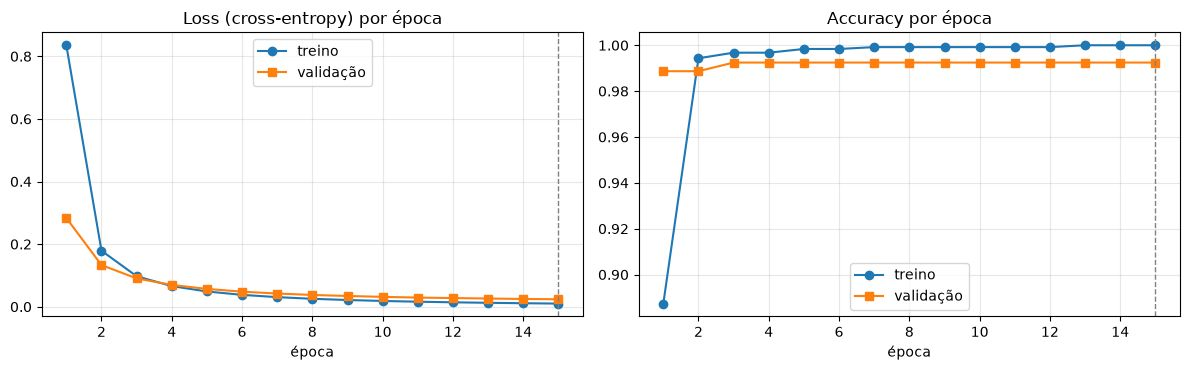

,epoch,train_loss,train_acc,val_loss,val_acc
0,1,0.8353,0.8874,0.2834,0.9887
1,2,0.1789,0.9943,0.1330,0.9887
2,3,0.0974,0.9968,0.0905,0.9925
3,4,0.0659,0.9968,0.0695,0.9925
4,5,0.0487,0.9984,0.0569,0.9925
5,6,0.0379,0.9984,0.0481,0.9925
6,7,0.0306,0.9992,0.0421,0.9925
7,8,0.0253,0.9992,0.0376,0.9925
8,9,0.0214,0.9992,0.0343,0.9925
9,10,0.0184,0.9992,0.0315,0.9925


In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
ax[0].plot(hist.epoch, hist.train_loss, "o-", label="treino"); ax[0].plot(hist.epoch, hist.val_loss, "s-", label="validação")
ax[0].set_title("Loss (cross-entropy) por época"); ax[0].set_xlabel("época"); ax[0].legend()
ax[1].plot(hist.epoch, hist.train_acc, "o-", label="treino"); ax[1].plot(hist.epoch, hist.val_acc, "s-", label="validação")
ax[1].set_title("Accuracy por época"); ax[1].set_xlabel("época"); ax[1].legend()
for a in ax: a.axvline(best[2], color="gray", ls="--", lw=1); a.grid(alpha=.3)
plt.tight_layout(); savefig("03_curvas_loss_acc"); plt.show()
hist.round(4)

### Avaliação no conjunto de teste

Para garantir que o modelo final é de fato *backbone congelado + nova `fc`*, montamos a ResNet-50 completa com a camada treinada e avaliamos o teste **a partir das imagens** (não do cache). O resultado tem de coincidir com a avaliação sobre as features.

In [11]:
model = resnet50(weights=weights, progress=False)
model.fc = nn.Linear(2048, len(CLASSES))
model.fc.load_state_dict(head.state_dict())
model = model.eval().to(DEVICE)

@torch.no_grad()
def predict(frame):
    dl = torch.utils.data.DataLoader(ImgDS(frame, preprocess), batch_size=64, num_workers=CONFIG["num_workers"])
    P = []
    for x, _ in dl:
        with torch.autocast(device_type="cuda", enabled=DEVICE == "cuda"):
            P.append(torch.softmax(model(x.to(DEVICE)).float(), 1).cpu())
    return torch.cat(P).numpy()

prob_test = predict(splits["test"])
y_test = splits["test"].label.map(cls2idx).values
pred_test = prob_test.argmax(1)
with torch.no_grad():
    pred_cache = head(F["test"][0].to(DEVICE)).argmax(1).cpu().numpy()
print("concordância imagem×cache:", (pred_cache == pred_test).mean())

acc = accuracy_score(y_test, pred_test); bacc = balanced_accuracy_score(y_test, pred_test)
cm = confusion_matrix(y_test, pred_test)
per_class = pd.DataFrame({"n_teste": cm.sum(1), "acertos": np.diag(cm), "accuracy_por_classe": np.diag(cm) / cm.sum(1)}, index=CLASSES)
print(f"accuracy global (teste): {acc:.4f} | balanced accuracy: {bacc:.4f}")
per_class.round(4)

concordância imagem×cache: 1.0
accuracy global (teste): 0.9962 | balanced accuracy: 0.9974


,n_teste,acertos,accuracy_por_classe
bike,54,53,0.9815
cars,63,63,1.0000
cats,30,30,1.0000
dogs,31,31,1.0000
flowers,32,32,1.0000
horses,28,28,1.0000
human,27,27,1.0000


In [12]:
print(classification_report(y_test, pred_test, target_names=CLASSES, digits=4))

              precision    recall  f1-score   support

        bike     1.0000    0.9815    0.9907        54
        cars     0.9844    1.0000    0.9921        63
        cats     1.0000    1.0000    1.0000        30
        dogs     1.0000    1.0000    1.0000        31
     flowers     1.0000    1.0000    1.0000        32
      horses     1.0000    1.0000    1.0000        28
       human     1.0000    1.0000    1.0000        27

    accuracy                         0.9962       265
   macro avg     0.9978    0.9974    0.9975       265
weighted avg     0.9963    0.9962    0.9962       265



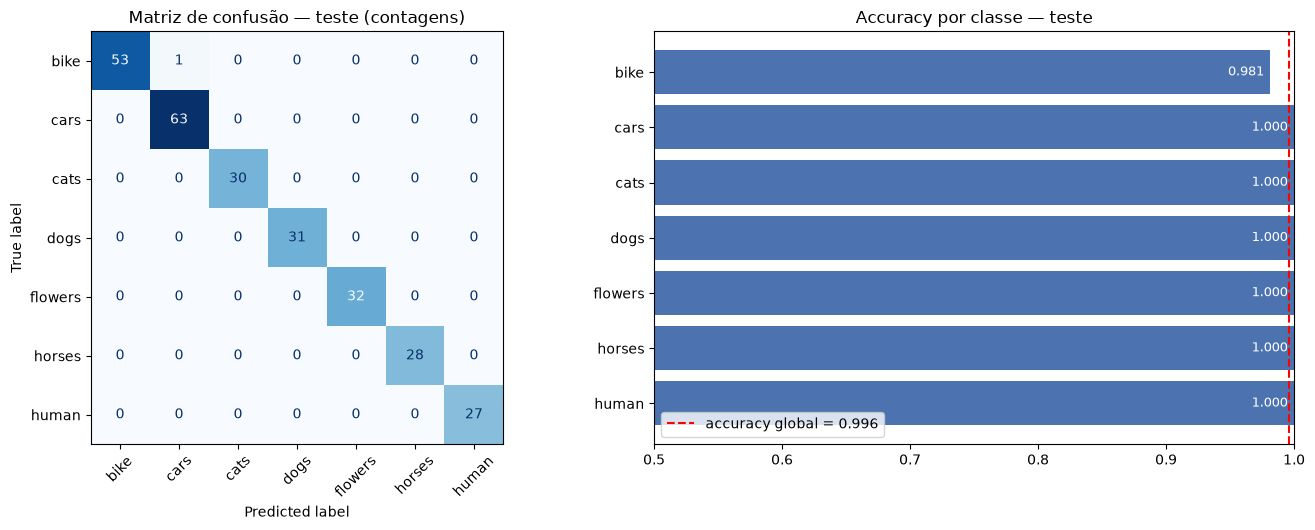

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5.4))
ConfusionMatrixDisplay(cm, display_labels=CLASSES).plot(ax=ax[0], cmap="Blues", colorbar=False, xticks_rotation=45)
ax[0].set_title("Matriz de confusão — teste (contagens)")
ax[1].barh(CLASSES[::-1], per_class.accuracy_por_classe.values[::-1], color="#4C72B0")
ax[1].axvline(acc, color="red", ls="--", label=f"accuracy global = {acc:.3f}")
for i, v in enumerate(per_class.accuracy_por_classe.values[::-1]): ax[1].text(v - 0.005, i, f"{v:.3f}", va="center", ha="right", color="white", fontsize=9)
ax[1].set_xlim(min(0.5, per_class.accuracy_por_classe.min() - 0.05), 1.0); ax[1].set_title("Accuracy por classe — teste"); ax[1].legend(loc="lower left")
plt.tight_layout(); savefig("04_confusao_e_acc_por_classe"); plt.show()

### Erros do modelo

Todas as imagens de teste classificadas errado, com a classe real, a prevista e a confiança.

erros no teste: 1


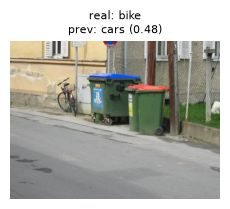

In [14]:
test_df = splits["test"].assign(pred=[CLASSES[i] for i in pred_test], conf=prob_test.max(1))
errors = test_df[test_df.label != test_df.pred].sort_values("conf", ascending=False)
print("erros no teste:", len(errors))
if len(errors):
    n = len(errors); cols = min(6, n); rows_ = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows_, cols, figsize=(2.4 * cols, 2.7 * rows_), squeeze=False)
    for a in axes.ravel(): a.axis("off")
    for a, (_, r) in zip(axes.ravel(), errors.iterrows()):
        a.imshow(Image.open(r.path).convert("RGB")); a.set_title(f"real: {r.label}\nprev: {r.pred} ({r.conf:.2f})", fontsize=8)
    plt.tight_layout(); savefig("05_erros_teste"); plt.show()

### Erros na validação e no treino

O teste tem poucas imagens por classe; olhar também os erros de treino/validação ajuda a entender **quais pares de classes** o espaço de features confunde.

In [15]:
with torch.no_grad():
    pred_all = {k: head(F[k][0].to(DEVICE)).argmax(1).cpu().numpy() for k in ["train", "val"]}
conf_pairs = Counter()
for k in ["train", "val"]:
    y = F[k][1].numpy()
    for t, p in zip(y[pred_all[k] != y], pred_all[k][pred_all[k] != y]):
        conf_pairs[(CLASSES[t], CLASSES[p])] += 1
for t, p in zip(y_test[pred_test != y_test], pred_test[pred_test != y_test]):
    conf_pairs[(CLASSES[t], CLASSES[p])] += 1
pd.DataFrame([(a, b, n) for (a, b), n in conf_pairs.most_common()], columns=["real", "previsto", "n (treino+val+teste)"])

,real,previsto,n (treino+val+teste)
0,cars,bike,1
1,cats,dogs,1
2,bike,cars,1


### Estrutura do espaço de features (t-SNE)

Projeção 2D dos vetores de 2048 dimensões do backbone congelado (Aula 02: projeção t-SNE/PCA para visualizar o espaço de embeddings). Clusters bem separados indicam que uma fronteira linear basta; sobreposições mostram onde estão as confusões.

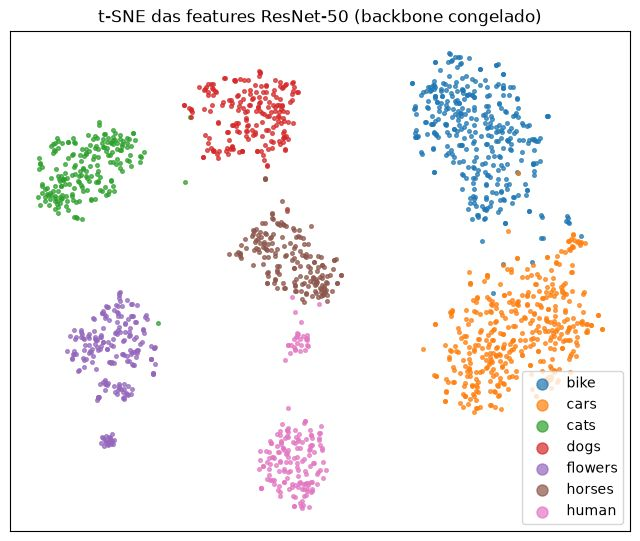

In [16]:
from sklearn.manifold import TSNE
Xall = torch.cat([F[k][0] for k in ["train", "val", "test"]]).numpy()
yall = torch.cat([F[k][1] for k in ["train", "val", "test"]]).numpy()
emb = TSNE(n_components=2, init="pca", perplexity=30, random_state=CONFIG["seed"]).fit_transform(Xall / np.linalg.norm(Xall, axis=1, keepdims=True))
plt.figure(figsize=(8, 6.5))
for i, c in enumerate(CLASSES):
    m = yall == i; plt.scatter(emb[m, 0], emb[m, 1], s=7, label=c, alpha=.7)
plt.legend(markerscale=3); plt.title("t-SNE das features ResNet-50 (backbone congelado)"); plt.xticks([]); plt.yticks([])
savefig("06_tsne_features"); plt.show()

## 6. Resumo dos resultados

In [17]:
results = dict(n_imagens=len(clean), n_treino=len(splits["train"]), n_val=len(splits["val"]), n_teste=len(splits["test"]),
               melhor_epoca=best[2], val_acc_melhor_epoca=float(hist.loc[best[2] - 1, "val_acc"]),
               test_accuracy=float(acc), test_balanced_accuracy=float(bacc),
               accuracy_por_classe=per_class.accuracy_por_classe.round(4).to_dict(),
               parametros_treinaveis=sum(p.numel() for p in head.parameters()))
(FIG_DIR / "results.json").write_text(json.dumps(results, indent=2, ensure_ascii=False), encoding="utf-8")
print(json.dumps(results, indent=2, ensure_ascii=False))

{
  "n_imagens": 1764,
  "n_treino": 1234,
  "n_val": 265,
  "n_teste": 265,
  "melhor_epoca": 15,
  "val_acc_melhor_epoca": 0.99245285987854,
  "test_accuracy": 0.9962264150943396,
  "test_balanced_accuracy": 0.9973544973544973,
  "accuracy_por_classe": {
    "bike": 0.9815,
    "cars": 1.0,
    "cats": 1.0,
    "dogs": 1.0,
    "flowers": 1.0,
    "horses": 1.0,
    "human": 1.0
  },
  "parametros_treinaveis": 14343
}


## 7. Evidências para o item 3.2 (sem novo treino)

O item 3.1 pede um único treino, e o 3.2 pede uma discussão. Para que a discussão se apoie em dados e não só em intuição, fazemos duas sondagens **sem treinar nada de novo**:

1. **Teste de estresse** (Aula 08): o modelo já treinado é avaliado no teste com cada transformação aplicada — se a accuracy de uma classe cai sob uma transformação, o modelo **não é invariante** a ela e a augmentation correspondente tenderia a ajudar; se não cai, a augmentation teria pouco a acrescentar (ou poderia até atrapalhar, como veremos nas classes em que a transformação muda o conteúdo).
2. **Normalização:** comparamos as features do backbone com e sem a normalização do ImageNet, usando um classificador por centroide mais próximo (não treinável) calculado nas features de treino.

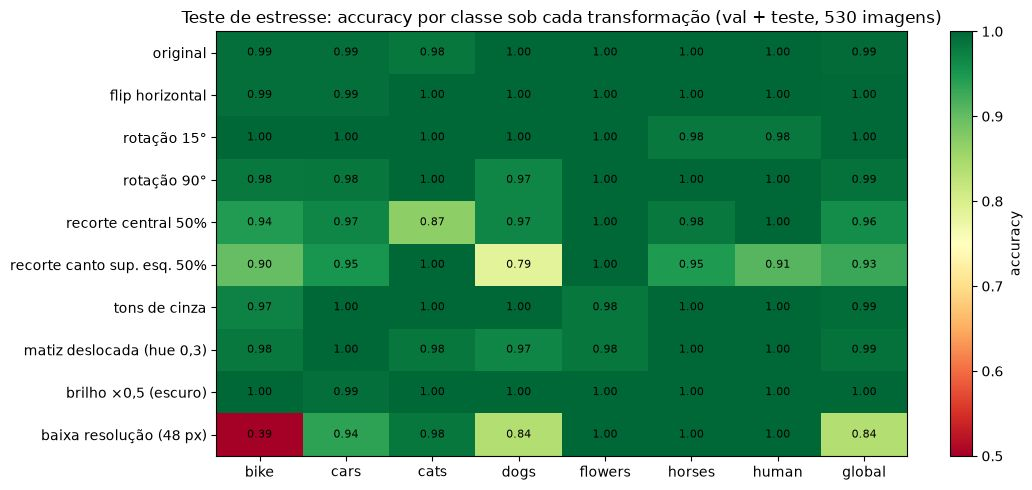

,bike,cars,cats,dogs,flowers,horses,human,global
original,0.991,0.992,0.984,1.000,1.000,1.000,1.000,0.994
flip horizontal,0.991,0.992,1.000,1.000,1.000,1.000,1.000,0.996
rotação 15°,1.000,1.000,1.000,1.000,1.000,0.982,0.982,0.996
rotação 90°,0.982,0.984,1.000,0.967,1.000,1.000,1.000,0.989
recorte central 50%,0.945,0.968,0.869,0.967,1.000,0.982,1.000,0.960
recorte canto sup. esq. 50%,0.899,0.952,1.000,0.787,1.000,0.945,0.909,0.928
tons de cinza,0.972,1.000,1.000,1.000,0.984,1.000,1.000,0.992
"matiz deslocada (hue 0,3)",0.982,1.000,0.984,0.967,0.984,1.000,1.000,0.989
"brilho ×0,5 (escuro)",1.000,0.992,1.000,1.000,1.000,1.000,1.000,0.998
baixa resolução (48 px),0.385,0.937,0.984,0.836,1.000,1.000,1.000,0.838


In [18]:
import torchvision.transforms as T
import torchvision.transforms.functional as TF

def norm_tail(img):
    return T.Normalize(weights.transforms().mean, weights.transforms().std)(TF.to_tensor(TF.center_crop(TF.resize(img, 232), 224)))

def lowres(img, side=48):
    small = img.resize((side, max(1, int(side * img.height / img.width))), Image.BILINEAR)
    return small.resize(img.size, Image.BILINEAR)

STRESS = {
    "original": lambda im: im,
    "flip horizontal": TF.hflip,
    "rotação 15°": lambda im: TF.rotate(im, 15, expand=False),
    "rotação 90°": lambda im: im.rotate(90, expand=True),
    "recorte central 50%": lambda im: TF.center_crop(im, [im.height // 2, im.width // 2]),
    "recorte canto sup. esq. 50%": lambda im: im.crop((0, 0, im.width // 2, im.height // 2)),
    "tons de cinza": lambda im: TF.to_grayscale(im, 3),
    "matiz deslocada (hue 0,3)": lambda im: TF.adjust_hue(im, 0.3),
    "brilho ×0,5 (escuro)": lambda im: TF.adjust_brightness(im, 0.5),
    "baixa resolução (48 px)": lowres,
}

@torch.no_grad()
def stress_eval(frame, fn):
    preds = []
    for i in range(0, len(frame), 64):
        x = torch.stack([norm_tail(fn(Image.open(p).convert("RGB"))) for p in frame.path[i:i + 64]]).to(DEVICE)
        with torch.autocast(device_type="cuda", enabled=DEVICE == "cuda"):
            preds.append(model(x).argmax(1).cpu())
    return torch.cat(preds).numpy()

stress_frame = pd.concat([splits["val"], splits["test"]])          # 530 imagens não vistas no treino
y_st = stress_frame.label.map(cls2idx).values
stress = {}
for name, fn in STRESS.items():
    pr = stress_eval(stress_frame, fn)
    stress[name] = {**{c: (pr[y_st == i] == i).mean() for i, c in enumerate(CLASSES)}, "global": (pr == y_st).mean()}
stress = pd.DataFrame(stress).T
plt.figure(figsize=(11, 5))
plt.imshow(stress.values, cmap="RdYlGn", vmin=0.5, vmax=1.0, aspect="auto")
for i in range(stress.shape[0]):
    for j in range(stress.shape[1]):
        plt.text(j, i, f"{stress.values[i, j]:.2f}", ha="center", va="center", fontsize=8)
plt.xticks(range(stress.shape[1]), stress.columns); plt.yticks(range(stress.shape[0]), stress.index)
plt.colorbar(label="accuracy"); plt.title("Teste de estresse: accuracy por classe sob cada transformação (val + teste, 530 imagens)")
plt.tight_layout(); savefig("07_teste_estresse"); plt.show()
stress.round(3)

In [19]:
pr_low = stress_eval(stress_frame, lowres)
print("Para onde vão as imagens em baixa resolução (48 px) mal classificadas, por classe real:")
pd.crosstab(pd.Series([CLASSES[i] for i in y_st], name="real"), pd.Series([CLASSES[i] for i in pr_low], name="previsto (48 px)"))

Para onde vão as imagens em baixa resolução (48 px) mal classificadas, por classe real:


previsto (48 px),bike,cars,cats,dogs,flowers,horses,human
real,,,,,,,
bike,42,15,18,0,2,5,27
cars,0,118,0,0,1,0,7
cats,0,0,60,1,0,0,0
dogs,0,0,4,51,0,4,2
flowers,0,0,0,0,63,0,0
horses,0,0,0,0,0,55,0
human,0,0,0,0,0,0,55


In [20]:
raw_tf = T.Compose([T.Resize(232), T.CenterCrop(224), T.ToTensor()])          # sem a normalização do ImageNet

@torch.no_grad()
def extract_with(frame, tf):
    dl = torch.utils.data.DataLoader(ImgDS(frame, tf), batch_size=64, num_workers=CONFIG["num_workers"])
    out = []
    for x, _ in dl:
        with torch.autocast(device_type="cuda", enabled=DEVICE == "cuda"):
            out.append(backbone(x.to(DEVICE)).float().cpu())
    return torch.cat(out)

def centroid_acc(Ftr, ytr, Fte, yte):
    Ftr, Fte = nn.functional.normalize(Ftr, dim=1), nn.functional.normalize(Fte, dim=1)
    C = torch.stack([Ftr[ytr == k].mean(0) for k in range(len(CLASSES))])
    return (Fte @ C.T).argmax(1).eq(yte).float().mean().item()

Fraw = {k: extract_with(splits[k], raw_tf) for k in ["train", "val"]}
cos_same = nn.functional.cosine_similarity(F["val"][0], Fraw["val"]).mean().item()
norm_res = pd.DataFrame({
    "accuracy centroide (val)": [centroid_acc(F["train"][0], F["train"][1], F["val"][0], F["val"][1]),
                                 centroid_acc(Fraw["train"], F["train"][1], Fraw["val"], F["val"][1])],
    "norma média das features": [F["val"][0].norm(dim=1).mean().item(), Fraw["val"].norm(dim=1).mean().item()],
}, index=["com Normalize(ImageNet)", "sem Normalize"])
print(f"similaridade de cosseno média entre a feature da mesma imagem com e sem normalização: {cos_same:.3f}")
with torch.no_grad():
    acc_head_raw = (head(Fraw["val"].to(DEVICE)).argmax(1).cpu() == F["val"][1]).float().mean().item()
print(f"head treinada com features normalizadas aplicada a features SEM normalização → accuracy val = {acc_head_raw:.3f}")
norm_res.round(4)

similaridade de cosseno média entre a feature da mesma imagem com e sem normalização: 0.920
head treinada com features normalizadas aplicada a features SEM normalização → accuracy val = 0.996


,accuracy centroide (val),norma média das features
com Normalize(ImageNet),0.9887,12.1442
sem Normalize,0.9887,12.0838


## 8. Item 3.2 — Análise e propostas de melhoria

### 8.1 O que os resultados do item 3.1 mostram

- **Desempenho no teto.** Com o backbone congelado e só 14.343 parâmetros treinados, o modelo erra **1 de 265** imagens de teste (accuracy 99,6%, balanced accuracy 99,7%). As curvas não mostram overfitting relevante: a loss de validação cai junto com a de treino até a época 15, e a accuracy de validação estabiliza em 99,2% a partir da época 3. O t-SNE mostra sete agrupamentos quase sem sobreposição: as features genéricas do ImageNet já separam essas categorias, e uma fronteira linear basta. Isso é esperado, porque bicicleta, carro, gato, cachorro, flor, cavalo e pessoa são conceitos presentes no próprio ImageNet.
- **Onde o modelo erra.** Em treino, validação e teste somados há só 3 erros: `bike→cars`, `cars→bike` e `cats→dogs`. O erro de teste é uma foto de rua em que a bicicleta ocupa uma fração pequena da cena, dominada por contêineres de lixo e asfalto, e a confiança é baixa (0,48). As classes `bike` e `cars` são **fotos de cena** (640×480, objeto pequeno, contexto urbano compartilhado), enquanto as outras cinco são **centradas no objeto**. A confusão vem do contexto, não do objeto.
- **O dataset tem atalhos de aquisição.** Cada classe veio de uma fonte diferente, com assinatura própria:
  - `bike` e `cars` são BMP 640×480;
  - `flowers` é PNG 128×128 com cores posterizadas;
  - `human` é JPG em retrato (proporção 0,73), quase sempre cavaleiros em traje de equitação;
  - `horses` é JPG 259×194.

  Também havia **39 duplicatas exatas**, todas dentro de `horses`, `human` e `bike`, e foram removidas. Um modelo pode acertar usando resolução, nitidez ou paleta em vez do objeto, e isso não aparece num teste da mesma distribuição.
- **Consequência para a melhoria:** com 99,6% no teste, ganhos de accuracy **não são mensuráveis** neste conjunto (cada imagem vale 0,4 p.p.). O objetivo de qualquer augmentation passa a ser **robustez a mudança de distribuição** (outras câmeras, resoluções e enquadramentos). Por isso apoiamos a discussão no teste de estresse da seção 7, que mede exatamente essa robustez.

### 8.2 Avaliação de cada opção

**1. Augmentation geométrica (flip horizontal, rotação leve, recorte aleatório).**
- *Flip horizontal:* **benéfico e seguro para todas as 7 classes.** Nenhuma delas tem semântica esquerda/direita: um carro ou um cavalo espelhado continua sendo carro ou cavalo. O estresse confirma que o modelo já é praticamente invariante (99,6% com flip), então o ganho esperado é pequeno, mas o risco é nulo. Seria a primeira augmentation a ligar.
- *Rotação leve (±10–15°):* **benéfica**. Há fotos de `bike` tiradas com a câmera girada, e fotos amadoras de `cats`/`dogs` raramente estão niveladas. Na rotação de 15° há uma queda pequena em `horses` e `human` (98,2%). Rotações fortes (90°) produzem imagens irreais para `horses`, `human`, `dogs` e `cats`, que estão sempre em pé pela gravidade: em `dogs` a accuracy cai para 96,7%. **Não usaria rotações grandes**, porque ensinariam o modelo a aceitar configurações que nunca ocorrem.
- *Recorte aleatório:* **benéfico com escala moderada, prejudicial se agressivo**, e é aqui que o estresse mostra o maior risco.
  - O recorte do canto superior esquerdo derruba `dogs` para 78,7%, `bike` para 89,9% e `human` para 90,9%.
  - O recorte central derruba `cats` para 86,9%.
  - Nas classes de cena (`bike`, `cars`), o objeto ocupa pouco espaço e fica fora do centro, então um recorte pequeno pode **não conter o objeto**. A imagem fica rotulada como "bike" mostrando só uma parede, o que é ruído de rótulo.
  - Em `human` (retrato vertical), recortes cortam cabeça ou pés.
  - Em `cats`/`dogs`, recortar o rosto remove o atributo que mais diferencia as duas classes.

  Usaria `RandomResizedCrop(224, scale=(0.6, 1.0))`, mantendo ao menos 60% da área, e nunca a escala padrão (0,08).

**2. Augmentation de cor (color jitter, grayscale aleatório).**
- *Brilho/contraste:* **benéfico.** `bike` tem várias fotos noturnas, e a variação de iluminação entre câmeras é a mudança de distribuição mais comum. O modelo já é robusto a escurecer pela metade (99,8%), então o ganho seria de robustez, não de accuracy.
- *Matiz (hue) e grayscale:* **aqui a classe importa.** `flowers` é a classe com maior saturação média (0,42, contra 0,15–0,36 nas outras), e a cor é um dos sinais que a distinguem. O estresse mostra um erro novo em `flowers` tanto com grayscale quanto com hue deslocado, e quedas pequenas em `bike` e `dogs`. Aplicar jitter forte de matiz ou grayscale com alta probabilidade **remove informação legítima de `flowers`** e pode atrapalhar sua aprendizagem.

  Por outro lado, a paleta posterizada de `flowers`, `horses` e `human` é um artefato de aquisição, não uma propriedade do objeto. Um jitter **leve** de saturação e grayscale com **p baixo (≈0,1, como na Aula 08)** reduz a dependência desse atalho sem apagar a cor. Para `cats`, `dogs` e `horses` a cor da pelagem não é discriminativa (há gatos e cães de todas as cores), então o jitter é seguro.

**3. Variação de escala (random resized crop, multi-scale training).**
- **É a melhoria mais importante para este dataset**, e o estresse mostra por quê. Com as imagens reduzidas para 48 px e reampliadas, a accuracy de `bike` despenca para **38,5%**, `dogs` vai a 83,6% e `cars` a 93,7%. Enquanto isso, `flowers`, `horses` e `human` ficam em 100%.
  - Bicicletas são estruturas finas (raios, quadro) que somem em baixa resolução, e o modelo não tem outra pista.
  - As três classes imunes são exatamente as de **origem em baixa resolução** (`flowers` 128×128, `human` ~188×257, `horses` ~259×194): o modelo já as viu "borradas". A tabela da seção 7 mostra para onde vão as bicicletas de 48 px: **27 viram `human`**, 18 viram `cats` e 15 viram `cars`. A maior parte vai para `human`, a classe de menor resolução nativa. Para o modelo, "imagem de baixa resolução" é em parte uma pista de classe.

  Isso é exatamente o atalho de aquisição descrito em 8.1. Treinar com **multi-escala** (`RandomResizedCrop` + *downscale-upscale* aleatório) desacopla resolução de classe e torna o modelo robusto a câmeras de menor qualidade.
- **Riscos:**
  - Para `bike` e `cars`, escalas pequenas podem tornar o objeto irreconhecível, então convém limitar a redução mínima.
  - Para `human` (retrato), o *center crop* atual já corta a altura. Usaria *resize* com preenchimento (*letterbox*) para preservar o corpo inteiro.

**4. Normalização com média e desvio do ImageNet.**
- **Já usada no item 3.1** via `weights.transforms()`, e é **obrigatória por construção**. Com o backbone congelado, os filtros e as estatísticas do BatchNorm (em modo `eval`) foram calibrados para entradas com essa média e desvio. Entradas em [0, 1] sem normalização deslocam todas as ativações, e nenhum parâmetro do backbone pode se adaptar, porque está congelado. É o "bug silencioso" da Aula 01.
- **O que o experimento mostrou, com honestidade:** neste dataset o efeito medido é pequeno. As features com e sem normalização têm cosseno médio de 0,92, o classificador por centroide dá 98,9% nos dois casos, e a cabeça treinada com features normalizadas mantém 99,6% quando recebe features sem normalização. As classes estão tão separadas que um deslocamento de 8% no espaço de features não muda nenhuma decisão. Isso **não** generaliza: em classes finas (raças de cão, defeitos industriais) ou em domínios distantes do ImageNet, a mesma distorção cai sobre fronteiras apertadas. Por isso a normalização é mantida como requisito de correção, e não como um hiperparâmetro "a testar".

### 8.3 Feature extraction ou fine-tuning: quando usar cada um

A decisão depende de duas variáveis: **quantos dados rotulados existem** e **quão distante o domínio está do pré-treino**. Combinando as Aulas 01, 03, 06 e 08:

| | **Domínio próximo do ImageNet** | **Domínio distante** (raio-X, metal fundido, satélite) |
|---|---|---|
| **Poucos dados** (centenas a poucos milhares) | **Feature extraction** (este dataset). As features já separam as classes, e treinar só a cabeça evita *overfitting* e *catastrophic forgetting*. Roda em segundos. | **Fine-tuning parcial** (últimos blocos + cabeça, LR diferencial ~1e-5 / 1e-3) com augmentation forte. Começar pelo *linear probe* como baseline. |
| **Muitos dados** (dezenas de milhares ou mais) | Fine-tuning das camadas finais ou completo, com LR baixo. Ganhos modestos sobre *feature extraction*. | **Fine-tuning completo** (ou até treino do zero com dados massivos). As features de baixo nível do ImageNet ainda ajudam a convergir. |

**Por que o lado esquerdo-superior se aplica aqui.** Com 1.234 imagens de treino e 7 categorias que o ImageNet cobre, o *feature extraction* atinge 99,6%. Um *fine-tuning* não tem margem mensurável para melhorar o teste. Ele custaria mais computação e atualizaria 23,5 M parâmetros com ~1.200 imagens, o que aumenta o risco de sobreajuste e de perda da robustez das features genéricas (Aula 06: o *full fine-tuning* ganha pouco no domínio-alvo e perde robustez fora da distribuição). A atualização das estatísticas de BatchNorm com batches pequenos também seria um ponto de atenção.

**Os outros dois projetos desta disciplina mostram o outro lado da tabela:**
- Na A1 (metal fundido, domínio distante, 910 imagens), o *linear probe* do ViT chega a 0,987 de balanced accuracy, e o *fine-tuning* com LR baixo leva a 1,000 na validação. As texturas de defeito não existem no ImageNet, e ajustar as camadas intermediárias compensa.
- Na A4.1 (raio-X), o *fine-tuning* de uma ResNet-18 pré-treinada levou o recall de COVID-19 de 41,7% (sem pré-treino) para 82–93%.

**Regra prática:** começar **sempre** por *feature extraction* / *linear probe* (barato, estável e um bom baseline). Só partir para *fine-tuning* (parcial antes de completo) se a validação mostrar que as features congeladas não bastam e houver dados para sustentar a adaptação.

### 8.4 O que eu testaria, em ordem

1. **Corrigir a avaliação antes de otimizar:** montar um conjunto de teste **com mudança de distribuição** (o próprio teste de estresse, ou imagens de outra fonte), porque o teste atual está saturado.
2. **Multi-escala** (`RandomResizedCrop(224, scale=(0.6, 1))` + *downscale* aleatório para 64–224 px), voltada ao atalho de resolução e ao colapso de `bike`.
3. **Flip horizontal + rotação ±10°**: risco zero, pequeno ganho de robustez.
4. **Brilho/contraste moderados + grayscale com p=0,1**, sem jitter de matiz forte por causa de `flowers`.
5. Com augmentation, as features não podem mais ser guardadas em cache: o backbone volta a rodar a cada época, ainda congelado. Se a robustez continuar insuficiente, o passo seguinte seria o *fine-tuning parcial* da `layer4` com LR diferencial (1e-5 no backbone e 1e-3 na cabeça, Aula 08).